# InceptionV3 Training - Skin Imperfections (9 Classes)
This notebook contains the full pipeline for training, evaluation, and CAM generation using the same dataset used in your EfficientNet notebook.
Run cells in order.

In [1]:
%pip install -q numpy pillow matplotlib seaborn pandas scikit-learn grad-cam opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Imports
import os
import csv
import copy
import time
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torchvision.models import Inception_V3_Weights

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

In [3]:
# Reproducibility + device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Training config
BATCH_SIZE = 32
NUM_WORKERS = 2
NUM_EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 1e-4
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15  # test ratio is remaining 0.15

Device: cuda


In [4]:
# Dataset discovery + transforms
train_transform = transforms.Compose([
    transforms.Resize((342, 342)),
    transforms.RandomResizedCrop(299),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((342, 342)),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class TransformedSubset(Dataset):
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.dataset[self.indices[idx]]


def _find_split_dirs(root: Path):
    split_map = {"train": None, "val": None, "test": None}
    aliases = {
        "train": {"train", "training"},
        "val": {"val", "valid", "validation"},
        "test": {"test"},
    }
    for dirpath, _, _ in os.walk(root):
        folder_name = Path(dirpath).name.lower()
        for key, names in aliases.items():
            if folder_name in names and split_map[key] is None:
                split_map[key] = Path(dirpath)
    return split_map


def _try_make_imagefolder(path: Path, transform=None):
    try:
        ds = ImageFolder(str(path), transform=transform)
        if len(ds.classes) > 0 and len(ds) > 0:
            return ds
    except Exception:
        pass
    return None


def _find_imagefolder_root(root: Path, max_depth: int = 6):
    candidates = [root]
    for depth in range(1, max_depth + 1):
        for p in root.rglob("*"):
            if p.is_dir() and len(p.relative_to(root).parts) == depth:
                candidates.append(p)

    seen = set()
    best_path = None
    best_count = -1
    for candidate in candidates:
        resolved = candidate.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)

        ds = _try_make_imagefolder(candidate)
        if ds is not None and len(ds) > best_count:
            best_path = candidate
            best_count = len(ds)

    return best_path


def _extract_valid_zip_and_find_root(root: Path):
    import zipfile

    zip_files = sorted(root.glob("*.zip"))
    if not zip_files:
        return None

    out_base = root / "_auto_extracted"
    out_base.mkdir(parents=True, exist_ok=True)

    for zf in zip_files:
        target = out_base / zf.stem
        if not target.exists():
            target.mkdir(parents=True, exist_ok=True)
            try:
                with zipfile.ZipFile(zf, "r") as z:
                    z.extractall(target)
                print(f"Extracted: {zf} -> {target}")
            except Exception as exc:
                print(f"Skip invalid zip {zf}: {exc}")
                continue

        found = _find_imagefolder_root(target, max_depth=7)
        if found is not None:
            return found
    return None


def _candidate_roots():
    env_root = os.getenv("DATASET_ROOT")
    cwd = Path.cwd()
    project_root = cwd.parents[1] if len(cwd.parents) >= 2 else cwd

    roots = [
        Path(env_root) if env_root else None,
        project_root / "dataset" / "Skin-Imperfections-9"
    ]
    return [r for r in roots if r is not None and r.exists()]


def resolve_data_root() -> Path:
    checked = []
    for root in _candidate_roots():
        checked.append(str(root))
        found = _find_imagefolder_root(root, max_depth=7)
        if found is not None:
            print("Resolved dataset root:", found)
            return found

    for root in _candidate_roots():
        extracted = _extract_valid_zip_and_find_root(root)
        if extracted is not None:
            print("Resolved dataset root from extracted zip:", extracted)
            return extracted

    raise RuntimeError(
        "No valid image dataset found. Checked roots: " + ", ".join(checked) +
        ". Set DATASET_ROOT to the folder that directly contains class subfolders with images."
    )


def build_datasets(data_root: Path):
    split_dirs = _find_split_dirs(data_root)

    if all(split_dirs.values()):
        train_root = _find_imagefolder_root(split_dirs["train"], max_depth=6)
        val_root = _find_imagefolder_root(split_dirs["val"], max_depth=6)
        test_root = _find_imagefolder_root(split_dirs["test"], max_depth=6)

        if all([train_root, val_root, test_root]):
            print("Using split roots:")
            print(" train ->", train_root)
            print(" val   ->", val_root)
            print(" test  ->", test_root)
            train_set = ImageFolder(str(train_root), transform=train_transform)
            val_set = ImageFolder(str(val_root), transform=eval_transform)
            test_set = ImageFolder(str(test_root), transform=eval_transform)
            class_names = train_set.classes
            return train_set, val_set, test_set, class_names

    direct_root = _find_imagefolder_root(data_root, max_depth=1) or data_root
    probe_ds = ImageFolder(str(direct_root))
    num_items = len(probe_ds)

    indices = np.arange(num_items)
    np.random.shuffle(indices)

    train_end = int(num_items * TRAIN_RATIO)
    val_end = train_end + int(num_items * VAL_RATIO)

    train_idx = indices[:train_end].tolist()
    val_idx = indices[train_end:val_end].tolist()
    test_idx = indices[val_end:].tolist()

    train_base = ImageFolder(str(direct_root), transform=train_transform)
    eval_base = ImageFolder(str(direct_root), transform=eval_transform)

    train_set = TransformedSubset(train_base, train_idx)
    val_set = TransformedSubset(eval_base, val_idx)
    test_set = TransformedSubset(eval_base, test_idx)
    class_names = probe_ds.classes
    return train_set, val_set, test_set, class_names

In [5]:
# Build datasets and dataloaders
data_root = resolve_data_root()
train_set, val_set, test_set, class_names = build_datasets(data_root)
num_classes = len(class_names)

print("Dataset root:", data_root)
print("Classes:", class_names)
print("Train/Val/Test sizes:", len(train_set), len(val_set), len(test_set))

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

Resolved dataset root: /media/aejaz/New Volume/Projects/DERMAVISION/dataset/Skin-Imperfections-9
Dataset root: /media/aejaz/New Volume/Projects/DERMAVISION/dataset/Skin-Imperfections-9
Classes: ['test', 'train', 'valid']
Train/Val/Test sizes: 6498 1392 1394


In [6]:
# Build InceptionV3 model
weights = Inception_V3_Weights.DEFAULT
model = models.inception_v3(weights=weights, aux_logits=True)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace main classifier head
in_features_main = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features_main, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes),
)

# Replace auxiliary head (used during training)
if model.AuxLogits is not None:
    in_features_aux = model.AuxLogits.fc.in_features
    model.AuxLogits.fc = nn.Linear(in_features_aux, num_classes)

# Unfreeze classifier heads
for param in model.fc.parameters():
    param.requires_grad = True
if model.AuxLogits is not None:
    for param in model.AuxLogits.fc.parameters():
        param.requires_grad = True

model = model.to(device)

In [7]:
# Quick sanity checks
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")
print("Main classifier head:", model.fc)
print("Aux classifier head:", model.AuxLogits.fc if model.AuxLogits is not None else None)

Trainable params: 1,052,934 / 25,396,198
Main classifier head: Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=2048, out_features=512, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=512, out_features=3, bias=True)
)
Aux classifier head: Linear(in_features=768, out_features=3, bias=True)


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
)

In [9]:
print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['test', 'train', 'valid']
Number of classes: 3


In [10]:
def _extract_logits(output):
    if isinstance(output, tuple):
        return output[0]
    if hasattr(output, "logits"):
        return output.logits
    return output


def _compute_train_loss(output, labels, criterion, aux_weight=0.4):
    if hasattr(output, "logits") and hasattr(output, "aux_logits") and output.aux_logits is not None:
        return criterion(output.logits, labels) + aux_weight * criterion(output.aux_logits, labels)
    if isinstance(output, tuple) and len(output) == 2:
        return criterion(output[0], labels) + aux_weight * criterion(output[1], labels)
    return criterion(_extract_logits(output), labels)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        output = model(inputs)
        loss = _compute_train_loss(output, labels, criterion)
        logits = _extract_logits(output)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    avg_loss = running_loss / max(total, 1)
    acc = 100.0 * correct / max(total, 1)
    return avg_loss, acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        output = model(inputs)
        logits = _extract_logits(output)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = running_loss / max(total, 1)
    acc = 100.0 * correct / max(total, 1)
    return avg_loss, acc, np.array(all_preds), np.array(all_labels)

In [11]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=NUM_EPOCHS,
    save_path="best_inceptionv3_skin_imperfection.pth",
    history_csv_path="inceptionv3_skin_imperfection_metrics.csv",
):
    start_time = time.time()
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    history = []
    best_epoch = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)

        _, _, train_pred, train_true = evaluate(model, train_loader, criterion, device)
        val_loss, val_acc, val_pred, val_true = evaluate(model, val_loader, criterion, device)

        train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(
            train_true,
            train_pred,
            average="weighted",
            zero_division=0,
        )
        val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
            val_true,
            val_pred,
            average="weighted",
            zero_division=0,
        )

        scheduler.step(val_acc)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_precision": float(train_precision),
            "train_recall": float(train_recall),
            "train_f1": float(train_f1),
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_precision": float(val_precision),
            "val_recall": float(val_recall),
            "val_f1": float(val_f1),
        })

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Train P/R/F1: {train_precision:.4f}/{train_recall:.4f}/{train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
            f"Val P/R/F1: {val_precision:.4f}/{val_recall:.4f}/{val_f1:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_weights = copy.deepcopy(model.state_dict())

    elapsed = time.time() - start_time
    print(f"Training complete in {elapsed/60:.1f} minutes")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")

    model.load_state_dict(best_weights)
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    if best_epoch == 0:
        best_epoch = epochs
    best_model_path = save_path.with_name(f"{save_path.stem}_best_epoch_{best_epoch}{save_path.suffix}")
    torch.save(best_weights, best_model_path)
    print(f"Best weights saved to: {best_model_path}")

    history_csv_path = Path(history_csv_path)
    history_csv_path = history_csv_path.with_name(f"{history_csv_path.stem}_best_epoch_{best_epoch}{history_csv_path.suffix}")
    history_csv_path.parent.mkdir(parents=True, exist_ok=True)

    with history_csv_path.open("w", newline="", encoding="utf-8") as csv_file:
        writer = csv.DictWriter(
            csv_file,
            fieldnames=[
                "epoch",
                "train_loss",
                "train_acc",
                "train_precision",
                "train_recall",
                "train_f1",
                "val_loss",
                "val_acc",
                "val_precision",
                "val_recall",
                "val_f1",
            ],
        )
        writer.writeheader()
        writer.writerows(history)

    print(f"Training/validation metrics saved to: {history_csv_path}")

    return model, history, best_val_acc, best_epoch, str(best_model_path), str(history_csv_path)

In [12]:
@torch.no_grad()
def evaluate_test(model, test_loader, criterion, device):
    test_loss, test_acc, y_pred, y_true = evaluate(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
    return test_loss, test_acc, y_pred, y_true

In [13]:
CHECKPOINT_PATH = Path.cwd() / "best_inceptionv3_skin_imperfection.pth"
HISTORY_CSV_PATH = Path.cwd() / "inceptionv3_skin_imperfection_metrics.csv"
print("Checkpoint will be saved at:", CHECKPOINT_PATH)
print("Training/validation CSV will be saved at:", HISTORY_CSV_PATH)

Checkpoint will be saved at: /media/aejaz/New Volume/Projects/DERMAVISION/InceptionV3/Skin-imperfection-9/best_inceptionv3_skin_imperfection.pth
Training/validation CSV will be saved at: /media/aejaz/New Volume/Projects/DERMAVISION/InceptionV3/Skin-imperfection-9/inceptionv3_skin_imperfection_metrics.csv


In [14]:
# Start training
model, history, best_val_acc, best_epoch, best_model_path, saved_history_csv_path = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=NUM_EPOCHS,
    save_path=str(CHECKPOINT_PATH),
    history_csv_path=str(HISTORY_CSV_PATH),
)

test_loss, test_acc, y_pred, y_true = evaluate_test(model, test_loader, criterion, device)

Epoch 001/50 | Train Loss: 1.1141 | Train Acc: 71.99% | Train P/R/F1: 0.5212/0.7219/0.6053 | Val Loss: 0.7909 | Val Acc: 70.83% | Val P/R/F1: 0.5017/0.7083/0.5874
Epoch 002/50 | Train Loss: 1.0928 | Train Acc: 72.19% | Train P/R/F1: 0.5212/0.7219/0.6053 | Val Loss: 0.7891 | Val Acc: 70.83% | Val P/R/F1: 0.5017/0.7083/0.5874
Epoch 003/50 | Train Loss: 1.0881 | Train Acc: 72.19% | Train P/R/F1: 0.5212/0.7219/0.6053 | Val Loss: 0.7998 | Val Acc: 70.83% | Val P/R/F1: 0.5017/0.7083/0.5874
Epoch 004/50 | Train Loss: 1.0926 | Train Acc: 72.19% | Train P/R/F1: 0.5212/0.7219/0.6053 | Val Loss: 0.8002 | Val Acc: 70.83% | Val P/R/F1: 0.5017/0.7083/0.5874
Epoch 005/50 | Train Loss: 1.0875 | Train Acc: 72.19% | Train P/R/F1: 0.5212/0.7219/0.6053 | Val Loss: 0.7891 | Val Acc: 70.83% | Val P/R/F1: 0.5017/0.7083/0.5874
Epoch 006/50 | Train Loss: 1.0759 | Train Acc: 72.19% | Train P/R/F1: 0.5212/0.7219/0.6053 | Val Loss: 0.7875 | Val Acc: 70.83% | Val P/R/F1: 0.5017/0.7083/0.5874
Epoch 007/50 | Train L

In [15]:
# Detailed evaluation artifacts with train/val/test split metrics
EVAL_PREFIX = "inceptionv3_skin_imperfection"
EVAL_DIR = Path.cwd() / f"{EVAL_PREFIX}_evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

if "history" not in locals() or len(history) == 0:
    raise RuntimeError("Train the model first so history and best_epoch are available.")

if "best_model_path" in locals() and Path(best_model_path).exists():
    model.load_state_dict(torch.load(Path(best_model_path), map_location=device))

@torch.no_grad()
def evaluate_split(split_name, loader):
    split_loss, split_acc, y_pred, y_true = evaluate(model, loader, criterion, device)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    return {
        "split": split_name,
        "loss": float(split_loss),
        "accuracy": float(split_acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "y_true": y_true,
        "y_pred": y_pred,
    }

split_metrics = {
    "train": evaluate_split("train", train_loader),
    "val": evaluate_split("val", val_loader),
    "test": evaluate_split("test", test_loader),
}

print("\nSplit-wise metrics")
print("=" * 80)
print(f"{'Split':<8} {'Acc':<10} {'Prec':<10} {'Recall':<10} {'F1':<10}")
print("-" * 80)
for split_name in ["train", "val", "test"]:
    m = split_metrics[split_name]
    print(f"{split_name:<8} {m['accuracy']:<10.4f} {m['precision']:<10.4f} {m['recall']:<10.4f} {m['f1_score']:<10.4f}")
print("=" * 80)

test_metrics = split_metrics["test"]
summary = {
    "class_names": class_names,
    "best_val_acc": float(best_val_acc),
    "split_metrics": {
        k: {
            "loss": v["loss"],
            "accuracy": v["accuracy"],
            "precision": v["precision"],
            "recall": v["recall"],
            "f1_score": v["f1_score"],
        }
        for k, v in split_metrics.items()
    },
}

with open(EVAL_DIR / f"final_metrics_best_epoch_{best_epoch}.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

report = classification_report(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
with open(EVAL_DIR / f"classification_report_best_epoch_{best_epoch}.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

pd.DataFrame(
    [
        {
            "split": k,
            "loss": v["loss"],
            "accuracy": v["accuracy"],
            "precision": v["precision"],
            "recall": v["recall"],
            "f1_score": v["f1_score"],
        }
        for k, v in split_metrics.items()
    ]
).to_csv(EVAL_DIR / f"split_metrics_best_epoch_{best_epoch}.csv", index=False)

cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"])
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(EVAL_DIR / f"confusion_matrix_best_epoch_{best_epoch}.csv")

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.tight_layout()
plt.savefig(EVAL_DIR / "confusion_matrix.png", dpi=200)
plt.close()

hist_df = pd.DataFrame(history)

plt.figure(figsize=(8, 5))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(EVAL_DIR / "loss_curve.png", dpi=200)
plt.close()

plt.figure(figsize=(8, 5))
plt.plot(hist_df["epoch"], hist_df["train_acc"], label="Train Acc")
plt.plot(hist_df["epoch"], hist_df["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(EVAL_DIR / "accuracy_curve.png", dpi=200)
plt.close()

print("Saved detailed evaluation to:", EVAL_DIR)

/tmp/ipykernel_22669/3600437054.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(Path(best_model_path), map_location=device))



Split-wise metrics
Split    Acc        Prec       Recall     F1        
--------------------------------------------------------------------------------
train    72.1914    0.5212     0.7219     0.6053    
val      70.8333    0.5017     0.7083     0.5874    
test     73.6729    0.5428     0.7367     0.6250    
Saved detailed evaluation to: /media/aejaz/New Volume/Projects/DERMAVISION/InceptionV3/Skin-imperfection-9/inceptionv3_skin_imperfection_evaluation


In [16]:
# Optional save:
torch.save(model.state_dict(), "inceptionv3_skin_imperfection_last.pth")

Working directory: /media/aejaz/New Volume/Projects/DERMAVISION/InceptionV3/Skin-imperfection-9
Project root: /media/aejaz/New Volume/Projects/DERMAVISION
Dataset relative path: dataset/Skin-Imperfections-9
Dataset root: /media/aejaz/New Volume/Projects/DERMAVISION/dataset/Skin-Imperfections-9
Test dir: /media/aejaz/New Volume/Projects/DERMAVISION/dataset/Skin-Imperfections-9/test
Using CSV label format: /media/aejaz/New Volume/Projects/DERMAVISION/dataset/Skin-Imperfections-9/test/_classes.csv
Device: cuda


/tmp/ipykernel_920668/1618156740.py:186: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_PATH, map_location=device)
/media/aejaz/New Volume/Proje

Skipped 4 incompatible key(s) during load.


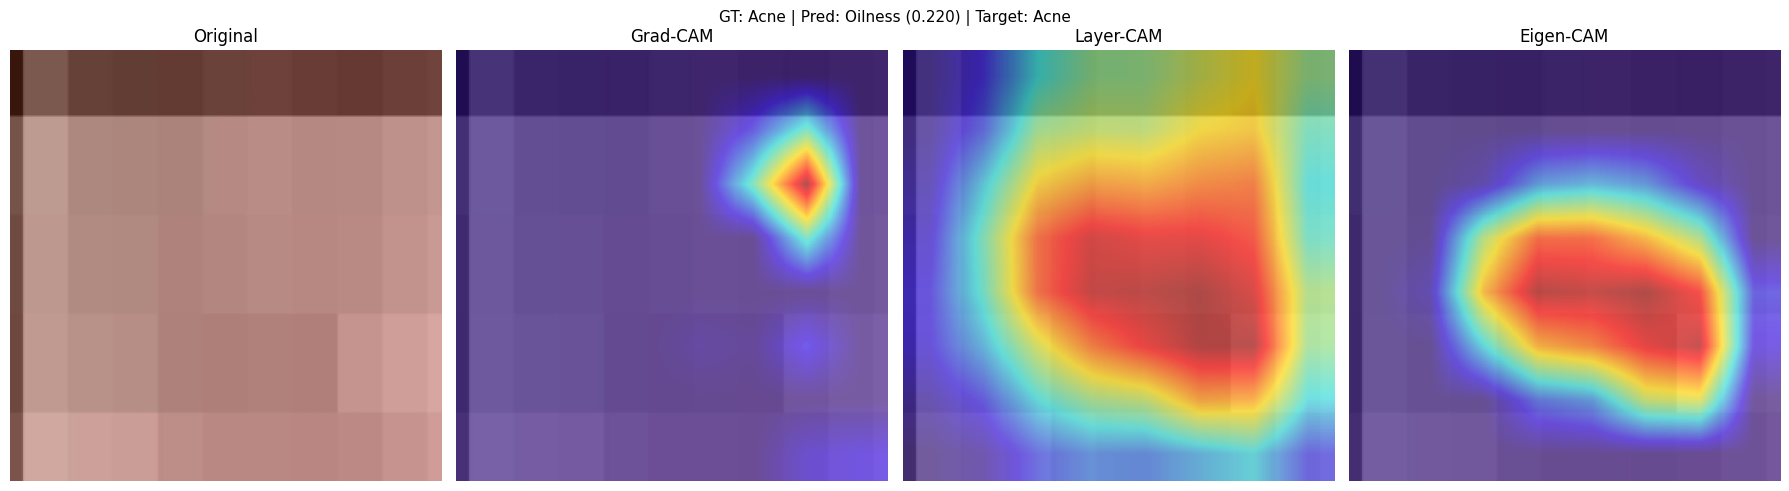

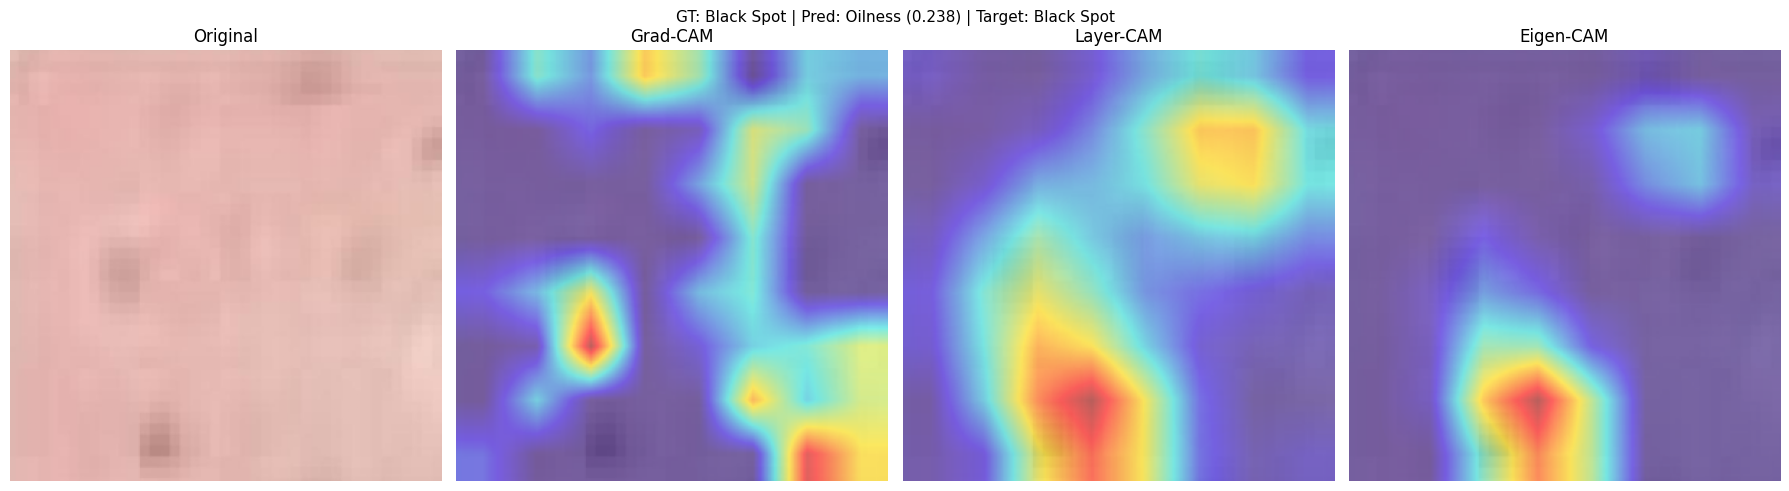

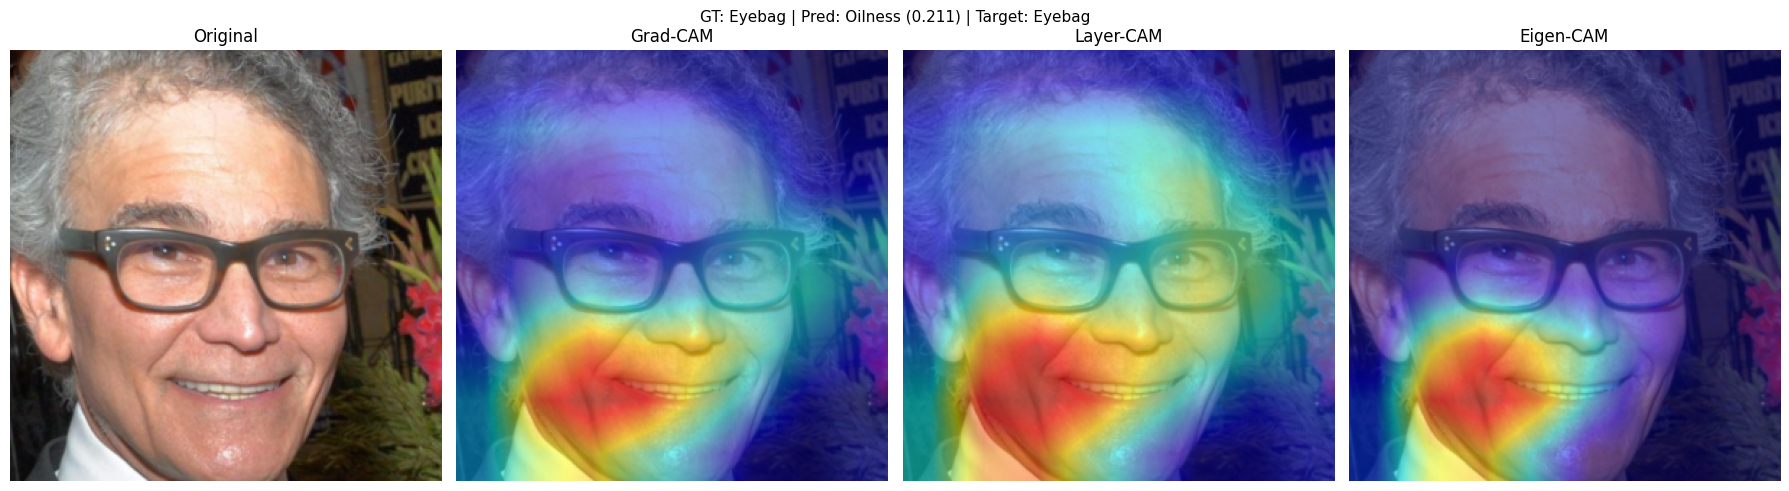

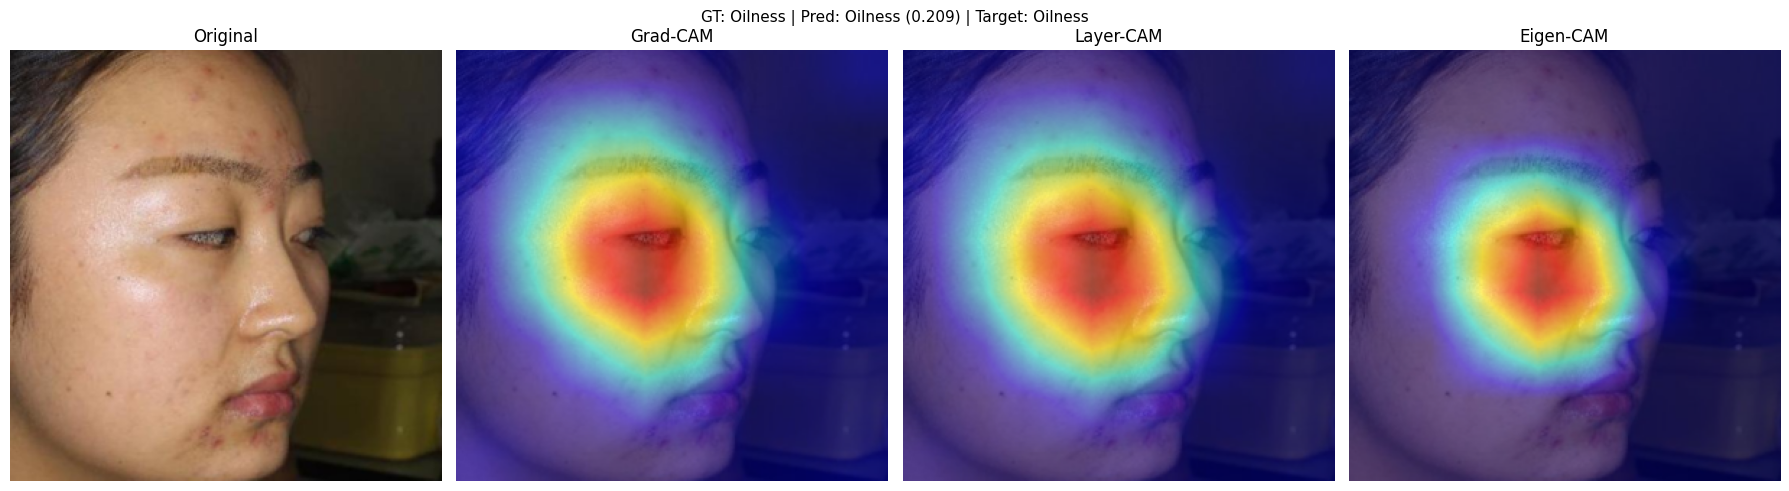

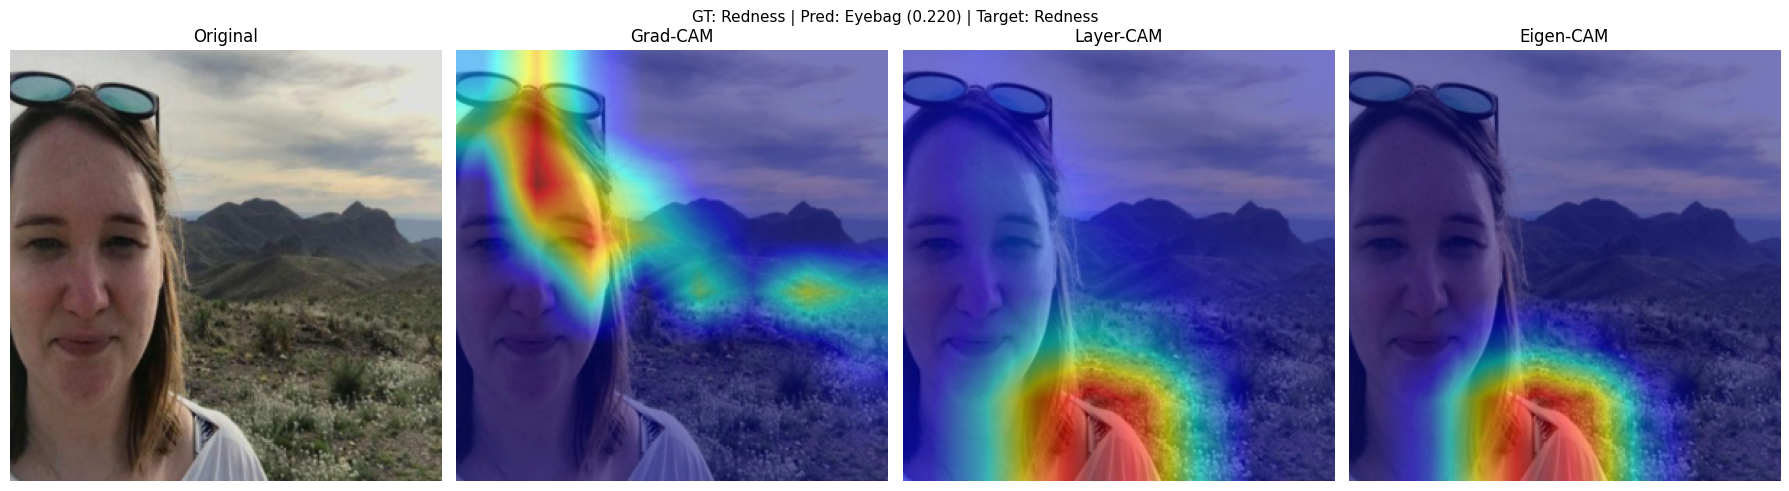

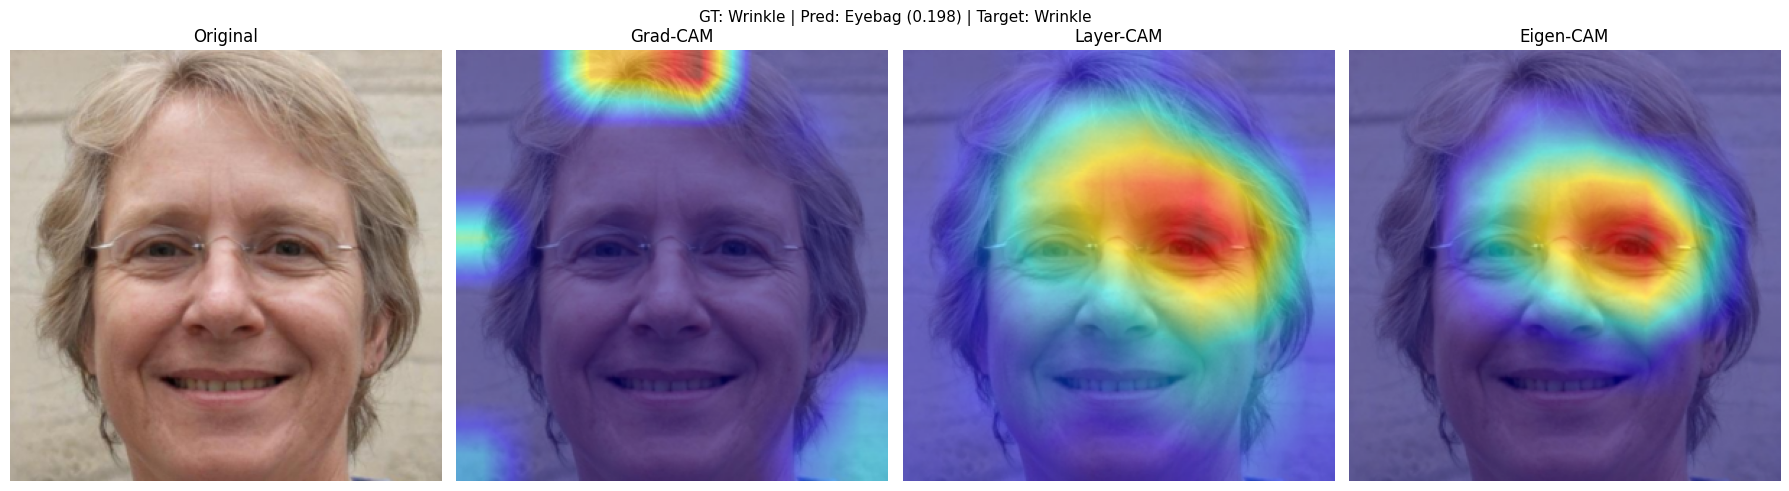

Done. CAM generated for 6 image(s).
Output folder: /media/aejaz/New Volume/Projects/DERMAVISION/InceptionV3/Skin-imperfection-9/cam_outputs_inceptionv3_simple
Pandas not available; skipping CSV summary.


In [1]:
# ==============================================
# SIMPLE CAM CELL (NO CUSTOM FUNCTIONS)
# Grad-CAM, Layer-CAM, Eigen-CAM
# Supports:
# 1) Class folders in test/<class_name>/*
# 2) CSV labels in test/_classes.csv (Skin-Imperfections-9)
# ==============================================

from pathlib import Path
import csv

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, models
from torchvision.transforms.functional import resize, center_crop

try:
    from pytorch_grad_cam import GradCAM, LayerCAM, EigenCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except Exception:
    %pip install -q grad-cam opencv-python
    from pytorch_grad_cam import GradCAM, LayerCAM, EigenCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cwd = Path.cwd()
DATASET_REL_PATH = Path("dataset") / "Skin-Imperfections-9"
MANUAL_DATASET_ROOT = None

project_root = cwd
while project_root != project_root.parent and not (project_root / DATASET_REL_PATH).exists():
    project_root = project_root.parent

DATASET_ROOT = Path(MANUAL_DATASET_ROOT) if MANUAL_DATASET_ROOT else (project_root / DATASET_REL_PATH)
TEST_DIR = DATASET_ROOT / "test"

USE_CSV_LABELS_IF_AVAILABLE = True
CSV_LABEL_FILE = "_classes.csv"
CSV_FILENAME_COL = "filename"

MANUAL_CLASS_NAMES = None

MANUAL_MODEL_PATH = None
MODEL_CANDIDATES = [
    cwd / "best_inceptionv3_skin_imperfection.pth",
    cwd / "inceptionv3_skin_imperfection_last.pth",
    project_root / "InceptionV3" / "Skin-imperfection-9" / "best_inceptionv3_skin_imperfection.pth",
    project_root / "InceptionV3" / "Skin-imperfection-9" / "inceptionv3_skin_imperfection_last.pth",
]

USE_MODEL_FROM_MEMORY_IF_AVAILABLE = True
ALLOW_PARTIAL_LOAD_IF_HEAD_MISMATCH = True

MAX_IMAGES_PER_CLASS = 1
USE_PREDICTED_CLASS_TARGET = False
CAM_OUTPUT_DIR = cwd / "cam_outputs_inceptionv3_simple"

print("Working directory:", cwd)
print("Project root:", project_root)
print("Dataset relative path:", DATASET_REL_PATH)
print("Dataset root:", DATASET_ROOT)
print("Test dir:", TEST_DIR)

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root not found: {DATASET_ROOT}\n"
        "Set MANUAL_DATASET_ROOT at the top of this cell if needed."
    )
if not TEST_DIR.exists():
    raise FileNotFoundError(
        f"Test directory not found: {TEST_DIR}\n"
        "Expected test folder under DATASET_ROOT."
    )

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
classes_csv_path = TEST_DIR / CSV_LABEL_FILE
images_by_class = {}

if USE_CSV_LABELS_IF_AVAILABLE and classes_csv_path.exists():
    print("Using CSV label format:", classes_csv_path)
    all_test_images = sorted([
        p for p in TEST_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ])
    name_to_paths = {}
    for p in all_test_images:
        name_to_paths.setdefault(p.name, []).append(p)

    with classes_csv_path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        header = reader.fieldnames or []
        class_names = [h for h in header if h and h != CSV_FILENAME_COL]

        if len(class_names) == 0:
            raise RuntimeError(
                f"No class columns found in {classes_csv_path}. "
                f"Expected a filename column '{CSV_FILENAME_COL}' and class columns."
            )

        images_by_class = {c: [] for c in class_names}
        for row in reader:
            filename = str(row.get(CSV_FILENAME_COL, "")).strip()
            if not filename:
                continue

            img_path = TEST_DIR / filename
            if not img_path.exists():
                matches = name_to_paths.get(Path(filename).name, [])
                if len(matches) > 0:
                    img_path = matches[0]
                else:
                    continue

            positive_classes = []
            for cname in class_names:
                raw = str(row.get(cname, "")).strip()
                try:
                    is_positive = float(raw) > 0
                except Exception:
                    is_positive = raw.lower() in {"1", "true", "yes", "y"}
                if is_positive:
                    positive_classes.append(cname)

            for cname in positive_classes:
                images_by_class[cname].append(img_path)
else:
    print("Using folder label format: test/<class_name>/*")
    class_dirs = sorted([d for d in TEST_DIR.iterdir() if d.is_dir()])
    class_names = [d.name for d in class_dirs]
    images_by_class = {}
    for class_dir in class_dirs:
        image_paths = sorted([
            p for p in class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS
        ])
        images_by_class[class_dir.name] = image_paths

if MANUAL_CLASS_NAMES is not None:
    class_names = list(MANUAL_CLASS_NAMES)
    for cname in class_names:
        images_by_class.setdefault(cname, [])

for cname in class_names:
    seen = set()
    unique_paths = []
    for p in images_by_class.get(cname, []):
        key = str(p)
        if key not in seen:
            seen.add(key)
            unique_paths.append(p)
    images_by_class[cname] = unique_paths

num_classes = len(class_names)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

if num_classes == 0:
    raise RuntimeError(f"No classes found in test data: {TEST_DIR}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

eval_transform = transforms.Compose([
    transforms.Resize((342, 342)),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

if MANUAL_MODEL_PATH:
    MODEL_PATH = Path(MANUAL_MODEL_PATH)
else:
    MODEL_PATH = next((p for p in MODEL_CANDIDATES if p.exists()), None)

if USE_MODEL_FROM_MEMORY_IF_AVAILABLE and "model" in globals():
    print("Using model already in memory.")
    model = model.to(device)
else:
    if MODEL_PATH is None:
        raise FileNotFoundError(
            "No checkpoint found automatically. Set MANUAL_MODEL_PATH at the top of this cell."
        )
    state_dict = torch.load(MODEL_PATH, map_location=device)
    if isinstance(state_dict, dict) and "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]
    if isinstance(state_dict, dict):
        state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

    model = models.inception_v3(weights=None, aux_logits=True)
    in_features_main = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features_main, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes),
    )
    if model.AuxLogits is not None:
        in_features_aux = model.AuxLogits.fc.in_features
        model.AuxLogits.fc = nn.Linear(in_features_aux, num_classes)

    model_state = model.state_dict()
    filtered_state = {}
    skipped_keys = []
    for k, v in state_dict.items():
        if k in model_state and model_state[k].shape == v.shape:
            filtered_state[k] = v
        else:
            skipped_keys.append(k)

    if len(skipped_keys) > 0:
        print(f"Skipped {len(skipped_keys)} incompatible key(s) during load.")

    model.load_state_dict(filtered_state, strict=False)

model = model.to(device)
model.eval()

# Grad-CAM needs gradients on the model graph, even if training used frozen layers.
for param in model.parameters():
    param.requires_grad = True

with torch.no_grad():
    dummy = torch.zeros(1, 3, 299, 299, device=device)
    out = model(dummy)
    model_outputs = out.logits if hasattr(out, "logits") else (out[0] if isinstance(out, tuple) else out)
model_num_classes = int(model_outputs.shape[1])

if model_num_classes != num_classes:
    print(f"Warning: model outputs {model_num_classes} classes but parsed labels have {num_classes}.")
    if model_num_classes < num_classes:
        class_names = class_names[:model_num_classes]
        images_by_class = {c: images_by_class.get(c, []) for c in class_names}
        num_classes = len(class_names)
        class_to_idx = {name: idx for idx, name in enumerate(class_names)}

TARGET_LAYER = model.Mixed_7c
target_layers = [TARGET_LAYER]

grad_cam = GradCAM(model=model, target_layers=target_layers)
layer_cam = LayerCAM(model=model, target_layers=target_layers)
eigen_cam = EigenCAM(model=model, target_layers=target_layers)

CAM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
records = []

for class_name in class_names:
    true_idx = class_to_idx[class_name]
    image_paths = images_by_class.get(class_name, [])
    if MAX_IMAGES_PER_CLASS is not None:
        image_paths = image_paths[:MAX_IMAGES_PER_CLASS]
    if len(image_paths) == 0:
        continue

    out_class_dir = CAM_OUTPUT_DIR / class_name
    out_class_dir.mkdir(parents=True, exist_ok=True)

    for img_path in image_paths:
        pil_img = Image.open(img_path).convert("RGB")
        vis_pil = center_crop(resize(pil_img, [342, 342]), [299, 299])
        rgb_img = np.array(vis_pil).astype(np.float32) / 255.0

        input_tensor = eval_transform(pil_img).unsqueeze(0).to(device)
        input_tensor.requires_grad_(True)
        with torch.no_grad():
            out = model(input_tensor)
            logits = out.logits if hasattr(out, "logits") else (out[0] if isinstance(out, tuple) else out)
            probs = torch.softmax(logits, dim=1)[0]
            pred_idx = int(torch.argmax(probs).item())
            pred_conf = float(probs[pred_idx].item())

        target_idx = pred_idx if USE_PREDICTED_CLASS_TARGET else true_idx
        if target_idx >= logits.shape[1]:
            continue
        targets = [ClassifierOutputTarget(target_idx)]

        model.zero_grad(set_to_none=True)
        cam_gc = grad_cam(input_tensor=input_tensor, targets=targets)[0]
        model.zero_grad(set_to_none=True)
        cam_lc = layer_cam(input_tensor=input_tensor, targets=targets)[0]
        model.zero_grad(set_to_none=True)
        cam_ec = eigen_cam(input_tensor=input_tensor, targets=targets)[0]

        overlay_gc = show_cam_on_image(rgb_img, cam_gc, use_rgb=True)
        overlay_lc = show_cam_on_image(rgb_img, cam_lc, use_rgb=True)
        overlay_ec = show_cam_on_image(rgb_img, cam_ec, use_rgb=True)

        pred_name = class_names[pred_idx] if pred_idx < len(class_names) else str(pred_idx)
        target_name = class_names[target_idx] if target_idx < len(class_names) else str(target_idx)

        fig, axes = plt.subplots(1, 4, figsize=(18, 5))
        axes[0].imshow(rgb_img)
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(overlay_gc)
        axes[1].set_title("Grad-CAM")
        axes[1].axis("off")

        axes[2].imshow(overlay_lc)
        axes[2].set_title("Layer-CAM")
        axes[2].axis("off")

        axes[3].imshow(overlay_ec)
        axes[3].set_title("Eigen-CAM")
        axes[3].axis("off")

        fig.suptitle(
            f"GT: {class_name} | Pred: {pred_name} ({pred_conf:.3f}) | Target: {target_name}",
            fontsize=11,
        )
        plt.tight_layout()

        out_file = out_class_dir / f"{img_path.stem}_cam_grid.png"
        fig.savefig(out_file, dpi=180, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        records.append({
            "class_name": class_name,
            "image_path": str(img_path),
            "prediction": pred_name,
            "prediction_confidence": pred_conf,
            "target": target_name,
            "output_file": str(out_file),
        })

print(f"Done. CAM generated for {len(records)} image(s).")
print("Output folder:", CAM_OUTPUT_DIR)

try:
    summary_csv = CAM_OUTPUT_DIR / "cam_summary.csv"
    pd.DataFrame(records).to_csv(summary_csv, index=False)
    print("Summary CSV:", summary_csv)
except Exception:
    print("Pandas not available; skipping CSV summary.")